In [1]:
import sys
sys.path.insert(0, '../lib')

In [2]:
import joblib
import typing
import pandas as pd
import numpy as np
import scipy
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.multitest

import common_data
import common_plots
import flow_sankey

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
common_plots.setup_plotting()

In [5]:
%config InlineBackend.figure_format = "retina"

In [6]:
pd.options.display.max_columns = 200

In [7]:
flow = pd.read_csv(common_data.RAW_FLOW, index_col=0)

In [8]:
ehr = pd.read_csv(common_data.CLINICAL, index_col=0)

In [9]:
ehr.BAL_performed.sum()

1741

In [10]:
ehr['has_flow'] = ehr.bal_barcode.isin(flow.bal_barcode)

In [11]:
ehr.has_flow.sum()

792

In [12]:
sc = common_data.get_sc_categorical_covariates()

In [13]:
ehr['has_sc'] = ehr.bal_barcode.isin(sc.index)

In [14]:
ehr.has_sc.sum()

263

In [15]:
bals = ehr.loc[ehr.BAL_performed].copy()
bals['bal_text'] = 'BAL'
bals['sc_text'] = 'No scRNA-seq'
bals.loc[bals.has_sc, 'sc_text'] = 'scRNA-seq'
bals['flow_text'] = 'No flow cytometry'
bals.loc[bals.has_flow, 'flow_text'] = 'Flow cytometry'
bals.loc[bals.has_sc & ~bals.has_flow, 'flow_text'] = 'No flow cytometry, scRNA-seq'

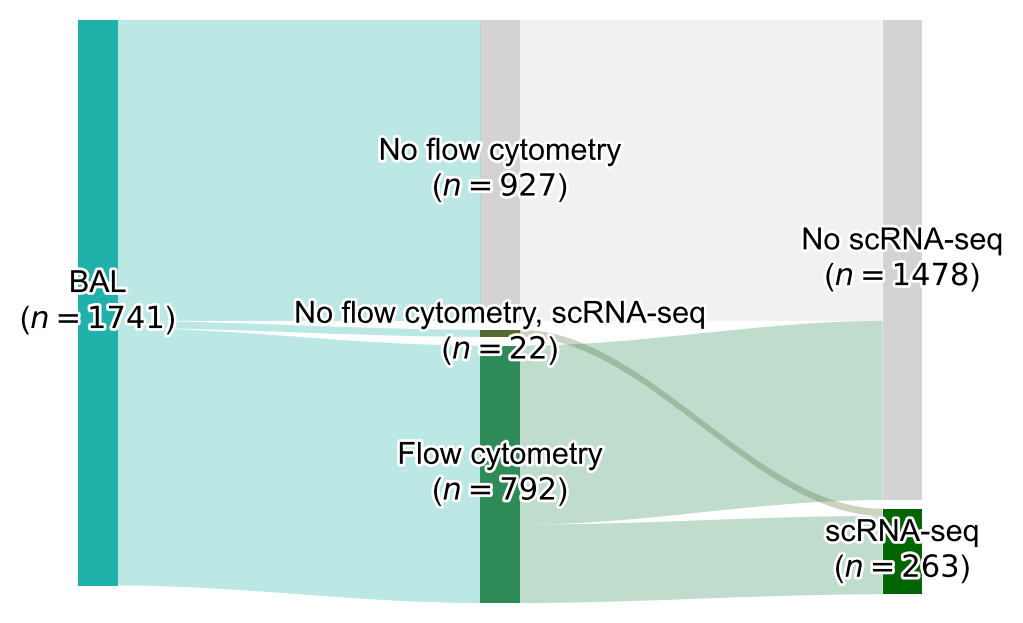

In [16]:
colors = {
    'BAL': 'lightseagreen',
    'Flow cytometry': 'seagreen',
    'No scRNA-seq':'lightgrey',
    'No flow cytometry':'lightgrey',
    'No flow cytometry, scRNA-seq':'darkolivegreen',
    'scRNA-seq':'darkgreen',
    'Skipped':'tab:red'
}

fig, ax = plt.subplots(figsize=(5, 3), constrained_layout=True)
diag = flow_sankey.Sankey(
    bals[['bal_text', 'flow_text', 'sc_text']],
    ax=ax,
    order=[
        ['BAL'],
        ['No flow cytometry','No flow cytometry, scRNA-seq','Flow cytometry',],
        ['No scRNA-seq','scRNA-seq']
    ],
    colors=colors,
    alpha=0.3,
    block_width=0.2,
    add_numbers=True,
    block_fontsize=11
)
diag.draw()
ax.tick_params(axis="x", pad=5, labelsize=16, bottom=False, labelbottom=False, top=True, labeltop=True)

fig.savefig('00_figures/10_sample_sankey.pdf')